# Measure correlation dimension of jets with Omnifold measurement

**TODO** add some description of what is happening in this notebook and disclaimer about it taking forever to run without good resources

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import glob
import pickle
import numpy as np
import awkward as ak
import uproot
import pandas as pd
import fastjet as fj

import utils
import visualize as vis

In [3]:
# Get ROOT TTrees and pass 190 flags
f = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_5Jul2025_MGPy8FxFxPlusNonStrong_syst_Test_withdd.root"
)
t = f["OmniTree"]
pass190 = ak.to_numpy(t["truth_pass190"].array())

f_pd = uproot.open(
    "/pscratch/sd/k/kgreif/data/TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_shuffled.root"
)
t_pd = f_pd["OmniTree"]
pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())

f_hv = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5.root"
)
t_hv = f_hv["OmniTree"]
pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())

f_data = uproot.open(
    "/pscratch/sd/k/kgreif/data/ZjetOmnifold_Nov11_data_WithTracks_slim_Systematics_shuffled.root"
)
t_data = f_data["OmniTree"]
pass190_data = np.ones(t_data.num_entries)

In [4]:
# For the sherpa prediction, load all of the available files
# Make sure to also add the non-strong piece
sherpa_files = [f"/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/sherpa/ZjetOmnifold_30Jul2025_Sherpa2211Truth_{syst}.root" for syst in ["mc16a_BFilter", "mc16d_BFilter", "mc16e_BFilter", "mc16a_CFilterBVeto", "mc16d_CFilterBVeto", "mc16e_CFilterBVeto", "mc16a_CVetoBVeto", "mc16d_CVetoBVeto", "mc16e_CVetoBVeto"]]
sherpa_files.append(
    "/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/sherpa/ZjetOmnifold_19Jun2025_NonStrong_posWrew_systJetIndex_Test.root"
)
sherpa_trees = [uproot.open(file)["OmniTree"] for file in sherpa_files]
sherpa_pass190 = [ak.to_numpy(tree["truth_pass190"].array()) for tree in sherpa_trees]

In [5]:
# Similar for the MadGraph prediction
mg_files = glob.glob("/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/madgraph/ZjetOmnifold*Test*.root")
mg_files.append(
    "/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/madgraph/ZjetOmnifold_19Jun2025_NonStrong_posWrew_systJetIndex_Test.root"
)
mg_trees = [uproot.open(file)["OmniTree"] for file in mg_files]
mg_pass190 = [ak.to_numpy(tree["truth_pass190"].array()) for tree in mg_trees]

In [6]:
# Load event weights for the Sherpa and MadGraph predictions
mg_weights_all = [ak.to_numpy(tree["weight_mc"].array())[mg_pass190[i] == 1] for i, tree in enumerate(mg_trees)]
mg_weights_all = np.concatenate(mg_weights_all)
sherpa_weights_all = [ak.to_numpy(tree["weight_mc"].array())[sherpa_pass190[i] == 1] for i, tree in enumerate(sherpa_trees)]
sherpa_weights_all = np.concatenate(sherpa_weights_all)

## Calculate EMDs

In [ ]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 330.0
ptmax = 370.0
etamax = 1.2
max_jets = 50000

# Set location for EMD storage, set to None to not save
emd_dir = "./emd_storage"
if not os.path.exists(emd_dir) and emd_dir is not None:
    os.makedirs(emd_dir)

In [ ]:
# Calculate EMDs for truth MC
utils.calculate_emds_from_file(
    t,
    pass190,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_mc_330to370.npz",
)

In [ ]:
# Calculate EMDs for truth pseudodata
utils.calculate_emds_from_file(
    t_pd,
    pass190_pd,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_pd_330to370.npz",
)

In [ ]:
# Calculate EMDs for HV MC
utils.calculate_emds_from_file(
    t_hv,
    pass190_hv,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_hv_330to370.npz",
)

In [ ]:
# Calculate EMDs for data
utils.calculate_emds_from_file(
    t_data,
    pass190_data,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=False,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/reco_data_330to370.npz",
)

In [ ]:
# Calculate EMDs for Sherpa
utils.calculate_emds_from_file(
    sherpa_trees,
    sherpa_pass190,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_sherpa_330to370.npz",
)

In [ ]:
# Calculate EMDs for madgraph
utils.calculate_emds_from_file(
    mg_trees,
    mg_pass190,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_madgraph_330to370.npz",
)

## Measurement with Pseudodata

### Histogramming

In [4]:
# Load all weights from the Omnifold pseudodata measurement
of_pseudodata = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="weights",
    mode="r",
)
of_pseudodata_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="hv_weights",
    mode="r",
)
print(of_pseudodata.head())

   weights_nominal  weights_ensemble_0  weights_ensemble_1  \
0         0.044341            0.056762            0.037897   
1         0.016487            0.017510            0.021068   
2         0.052124            0.048983            0.050069   
3         0.009146            0.007646            0.009730   
4         0.068637            0.050307            0.076978   

   weights_ensemble_2  weights_ensemble_3  weights_ensemble_4  \
0            0.038798            0.048447            0.043870   
1            0.012138            0.016708            0.013613   
2            0.054199            0.062180            0.050857   
3            0.009916            0.008168            0.009630   
4            0.069168            0.057254            0.070570   

   weights_ensemble_5  weights_ensemble_6  weights_ensemble_7  \
0            0.047447            0.035405            0.047906   
1            0.017815            0.012283            0.015292   
2            0.052436            0.048343

In [ ]:
# Create dictionary describing all of the histograms needed for the pseudodata measurement
nominal_emds = "./emd_storage/truth_mc_330to370.npz"
truthpd_emds = "./emd_storage/truth_pd_330to370.npz"
hv_emds = "./emd_storage/truth_hv_330to370.npz"

n_init_weights = [name for name in of_pseudodata.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_data_" in name]
nominal_weights = {
    "prior": of_pseudodata["weight_mc"][pass190 == 1],
    "nominal": of_pseudodata["weights_nominal"][pass190 == 1],
    **{f"ensemble_{i}": of_pseudodata[name][pass190 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_pseudodata[name][pass190 == 1] for i, name in enumerate(dbootstrap_weights)},
    "trackEffMain": of_pseudodata["weights_trackEffMain"][pass190 == 1],
    "trackEffJet": of_pseudodata["weights_trackEffJet"][pass190 == 1],
    "trackFake": of_pseudodata["weights_trackFake"][pass190 == 1],
    "trackPtScale": of_pseudodata["weights_trackPtScale"][pass190 == 1],
    "muonCalID": of_pseudodata["weights_muonCalID"][pass190 == 1],
    "muonCalMS": of_pseudodata["weights_muonCalMS"][pass190 == 1],
    "muonCalResBias": of_pseudodata["weights_muonCalResBias"][pass190 == 1],
    "muonCalScale": of_pseudodata["weights_muonCalScale"][pass190 == 1],
    "muonEffReco": of_pseudodata["weights_muonEffReco"][pass190 == 1],
    "muonEffIso": of_pseudodata["weights_muonEffIso"][pass190 == 1],
    "muonEffTrack": of_pseudodata["weights_muonEffTrack"][pass190 == 1],
    "muonEffTrig": of_pseudodata["weights_muonEffTrig"][pass190 == 1],
    "dd": of_pseudodata["weights_dd"][pass190 == 1],
    "target_dd": of_pseudodata["target_dd"][pass190 == 1],
}
truthpd_weights = {
    "truthpd": ak.to_numpy(t_pd["weight_mc"].array())[pass190_pd == 1],
}
hv_weights = {
    "hv": of_pseudodata_hv["weights_nominal"][pass190_hv == 1],
}


In [18]:
print(nominal_weights.keys())

dict_keys(['prior', 'nominal', 'ensemble_0', 'ensemble_1', 'ensemble_2', 'ensemble_3', 'ensemble_4', 'ensemble_5', 'ensemble_6', 'ensemble_7', 'ensemble_8', 'ensemble_9', 'bootstrap_data_0', 'bootstrap_data_1', 'bootstrap_data_2', 'bootstrap_data_3', 'bootstrap_data_4', 'bootstrap_data_5', 'bootstrap_data_6', 'bootstrap_data_7', 'bootstrap_data_8', 'bootstrap_data_9', 'bootstrap_data_10', 'bootstrap_data_11', 'bootstrap_data_12', 'bootstrap_data_13', 'bootstrap_data_14', 'bootstrap_data_15', 'bootstrap_data_16', 'bootstrap_data_17', 'bootstrap_data_18', 'bootstrap_data_19', 'bootstrap_data_20', 'bootstrap_data_21', 'bootstrap_data_22', 'bootstrap_data_23', 'bootstrap_data_24', 'bootstrap_data_25', 'bootstrap_data_26', 'bootstrap_data_27', 'bootstrap_data_28', 'bootstrap_data_29', 'bootstrap_data_30', 'bootstrap_data_31', 'bootstrap_data_32', 'bootstrap_data_33', 'bootstrap_data_34', 'bootstrap_data_35', 'bootstrap_data_36', 'bootstrap_data_37', 'bootstrap_data_38', 'bootstrap_data_39',

In [6]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(120), 25)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    nominal_emds, nominal_weights, bins, n_jobs=-1
)
truthpd_hists = utils.calculate_correlation_dimension_from_file(
    truthpd_emds, truthpd_weights, bins, n_jobs=-1
)
hv_hists = utils.calculate_correlation_dimension_from_file(
    hv_emds, hv_weights, bins, n_jobs=-1
)

all_hists = {
    **nominal_hists,
    **truthpd_hists,
    **hv_hists,
}

Loading EMDs from ./emd_storage/truth_mc_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 120 weight sets using dask with 256 workers...


Processing weight sets:   0%|          | 0/120 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets:   1%|          | 1/120 [00:25<50:10, 25.29s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets:   2%|▏         | 2/120 [00:44<42:49, 21.77s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-pa

Loading EMDs from ./emd_storage/truth_pd_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 1 weight sets using dask with 256 workers...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets: 100%|██████████| 1/1 [00:19<00:00, 19.36s/set]


Loading EMDs from ./emd_storage/truth_hv_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 1 weight sets using dask with 256 workers...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets: 100%|██████████| 1/1 [00:18<00:00, 18.82s/set]


In [7]:
# Pickle the histograms
hist_dir = "./hist_storage"
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)
with open(os.path.join(hist_dir, "pd_hists_330to370.pkl"), "wb") as f:
    pickle.dump(all_hists, f)


### Plotting

In [ ]:
# Load the histograms
with open(os.path.join(hist_dir, "pd_hists_330to370.pkl"), "rb") as f:
    all_hists = pickle.load(f)

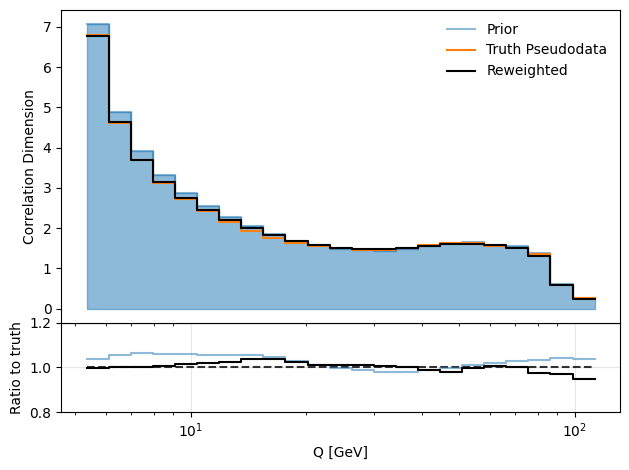

In [ ]:
# Plot comparison to truth pseudodata (no uncertainties)
comp = vis.compare_to_target(
    all_hists,
    log_xscale=True,
    linear_yscale=True,
    ylabel="Correlation Dimension",
    xlabel="Q [GeV]",
)

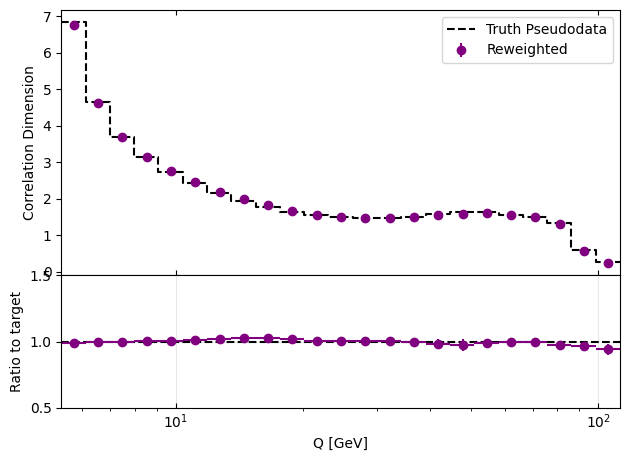

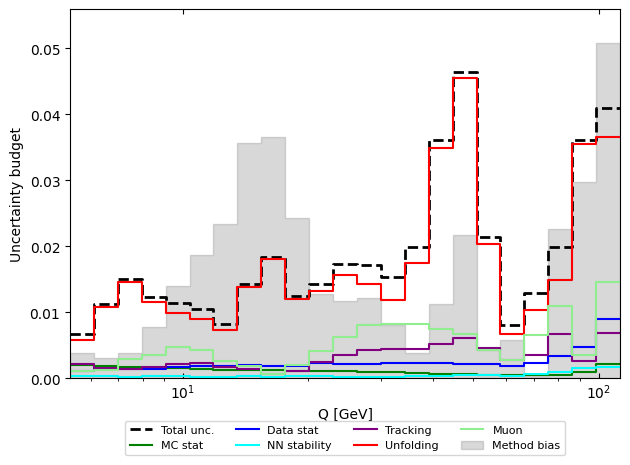

In [20]:
# Plot pseudo-measurement and uncertainty budget
import visualize as vis
xsec, budget = vis.plot_measurement_with_uncertainties(
    all_hists,
    figsize=(6.4, 4.8),
    color="purple",
    linear_yscale=True,
)
xsec.show()
budget.show()

## Measurement with data

### Histogramming

In [8]:
# Load all weights from the Omnifold data measurement
of_data = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="weights",
    mode="r",
)
of_data_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="hv_weights",
    mode="r",
)

         weights_nominal  weights_ensemble_0  weights_ensemble_1  \
0               0.019592            0.018763            0.029048   
1               0.010363            0.009342            0.011479   
2               0.026572            0.035993            0.020383   
3               0.005498            0.005669            0.003847   
4               0.032507            0.029171            0.046842   
...                  ...                 ...                 ...   
1191153         0.095478            0.095154            0.078880   
1191154         0.173260            0.171871            0.139589   
1191155         0.365533            0.447393            0.395555   
1191156         0.041051            0.033350            0.048673   
1191157         0.060449            0.051020            0.042651   

         weights_ensemble_2  weights_ensemble_3  weights_ensemble_4  \
0                  0.016016            0.023356            0.022848   
1                  0.010702            0.

In [9]:
of_data

,weights_nominal,weights_ensemble_0,weights_ensemble_1,weights_ensemble_2,weights_ensemble_3,weights_ensemble_4,weights_ensemble_5,weights_ensemble_6,weights_ensemble_7,weights_ensemble_8,...,weights_bootstrap_data_88,weights_bootstrap_data_89,weights_bootstrap_data_90,weights_bootstrap_data_91,weights_bootstrap_data_92,weights_bootstrap_data_93,weights_bootstrap_data_94,weights_bootstrap_data_95,target_dd,weight_mc
0,0.019592,0.018763,0.029048,0.016016,0.023356,0.022848,0.025532,0.014842,0.016436,0.015387,...,0.018687,0.023392,0.014746,0.015937,0.013888,0.024360,0.018674,0.027123,0.009246,0.011127
1,0.010363,0.009342,0.011479,0.010702,0.010226,0.008421,0.014482,0.011025,0.009054,0.008790,...,0.010471,0.012782,0.009028,0.010704,0.011389,0.014547,0.009113,0.013198,0.018261,0.013088
2,0.026572,0.035993,0.020383,0.020710,0.024478,0.041447,0.023266,0.021614,0.024849,0.025609,...,0.034246,0.024030,0.023463,0.026045,0.021916,0.017784,0.027890,0.023908,0.010568,0.013480
3,0.005498,0.005669,0.003847,0.005930,0.004603,0.005730,0.004651,0.006183,0.006582,0.005441,...,0.005812,0.004532,0.006062,0.004782,0.006257,0.003793,0.004615,0.004435,0.009549,0.012309
4,0.032507,0.029171,0.046842,0.026782,0.041058,0.019391,0.044027,0.028941,0.027710,0.041138,...,0.032466,0.037530,0.025392,0.041441,0.032669,0.056504,0.026023,0.051991,0.020096,0.010186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191153,0.095478,0.095154,0.078880,0.091924,0.084730,0.099363,0.072010,0.111254,0.104016,0.107790,...,0.130553,0.101481,0.128490,0.141673,0.148707,0.097235,0.115228,0.107630,0.101308,0.167579
1191154,0.173260,0.171871,0.139589,0.181619,0.150568,0.176645,0.218460,0.204957,0.122994,0.145901,...,0.191412,0.240834,0.254600,0.238909,0.228527,0.208348,0.207921,0.217870,0.668430,1.368566
1191155,0.365533,0.447393,0.395555,0.347787,0.328472,0.364830,0.360717,0.349040,0.366725,0.373351,...,0.336015,0.388210,0.376583,0.326897,0.334951,0.344864,0.313174,0.407599,0.325114,0.822971
1191156,0.041051,0.033350,0.048673,0.033291,0.050213,0.030546,0.054681,0.030267,0.038965,0.050655,...,0.039116,0.048242,0.038867,0.041213,0.041541,0.055330,0.041025,0.051092,0.098256,0.172585


In [10]:
# Create dictionary describing all of the histograms needed for the data measurement
nominal_emds = "./emd_storage/truth_mc_330to370.npz"
hv_emds = "./emd_storage/truth_hv_330to370.npz"
mg_emds = "./emd_storage/truth_madgraph_330to370.npz"
sherpa_emds = "./emd_storage/truth_sherpa_330to370.npz"

n_init_weights = [name for name in of_data.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [
    name for name in of_data.keys() if "weights_bootstrap_data_" in name
]
nominal_weights = {
    "prior": of_data["weight_mc"][pass190 == 1],
    "nominal": of_data["weights_nominal"][pass190 == 1],
    **{
        f"ensemble_{i}": of_data[name][pass190 == 1]
        for i, name in enumerate(n_init_weights)
    },
    **{
        f"bootstrap_data_{i}": of_data[name][pass190 == 1]
        for i, name in enumerate(dbootstrap_weights)
    },
    "trackEffMain": of_data["weights_trackEffMain"][pass190 == 1],
    "trackEffJet": of_data["weights_trackEffJet"][pass190 == 1],
    "trackFake": of_data["weights_trackFake"][pass190 == 1],
    "trackPtScale": of_data["weights_trackPtScale"][pass190 == 1],
    "muonCalID": of_data["weights_muonCalID"][pass190 == 1],
    "muonCalMS": of_data["weights_muonCalMS"][pass190 == 1],
    "muonCalResBias": of_data["weights_muonCalResBias"][pass190 == 1],
    "muonCalScale": of_data["weights_muonCalScale"][pass190 == 1],
    "muonEffReco": of_data["weights_muonEffReco"][pass190 == 1],
    "muonEffIso": of_data["weights_muonEffIso"][pass190 == 1],
    "muonEffTrack": of_data["weights_muonEffTrack"][pass190 == 1],
    "muonEffTrig": of_data["weights_muonEffTrig"][pass190 == 1],
    "dd": of_data["weights_dd"][pass190 == 1],
    "target_dd": of_data["target_dd"][pass190 == 1],
}
hv_weights = {
    "hv": of_data_hv["weights_nominal"][pass190_hv == 1],
}
madgraph_weights = {"madgraph": mg_weights_all}
sherpa_weights = {"sherpa": sherpa_weights_all}

In [11]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(120), 25)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    nominal_emds, nominal_weights, bins, n_jobs=-1
)
hv_hists = utils.calculate_correlation_dimension_from_file(hv_emds, hv_weights, bins)
madgraph_hists = utils.calculate_correlation_dimension_from_file(
    mg_emds, madgraph_weights, bins
)
sherpa_hists = utils.calculate_correlation_dimension_from_file(
    sherpa_emds, sherpa_weights, bins
)

all_hists = {
    **nominal_hists,
    **hv_hists,
    **madgraph_hists,
    **sherpa_hists,
}

Loading EMDs from ./emd_storage/truth_mc_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 122 weight sets using dask with 256 workers...


Processing weight sets:   0%|          | 0/122 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets:   1%|          | 1/122 [00:22<45:15, 22.44s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets:   2%|▏         | 2/122 [00:40<39:57, 19.98s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-pa

Loading EMDs from ./emd_storage/truth_hv_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 1 weight sets using dask with 1 workers...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets: 100%|██████████| 1/1 [05:02<00:00, 302.19s/set]


Loading EMDs from ./emd_storage/truth_madgraph_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 1 weight sets using dask with 1 workers...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets: 100%|██████████| 1/1 [05:13<00:00, 313.42s/set]


Loading EMDs from ./emd_storage/truth_sherpa_330to370.npz...
Loaded EMDs with shape (50000, 50000)
Loaded event indices with shape (50000,)
Converting EMDs to dask array with chunk size 3000...
Processing 1 weight sets using dask with 1 workers...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(
Processing weight sets: 100%|██████████| 1/1 [05:06<00:00, 306.37s/set]


In [12]:
# Pickle the histograms
hist_dir = "./hist_storage"
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)
with open(os.path.join(hist_dir, "data_hists_330to370.pkl"), "wb") as f:
    pickle.dump(all_hists, f)

In [13]:
# Load the histograms
with open(os.path.join(hist_dir, "data_hists_330to370.pkl"), "rb") as f:
    all_hists = pickle.load(f)

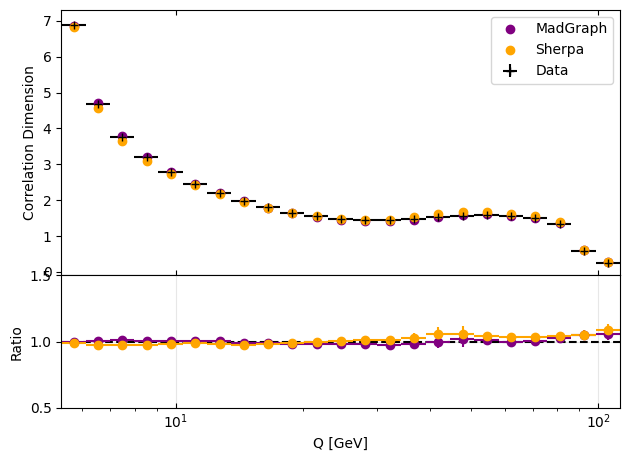

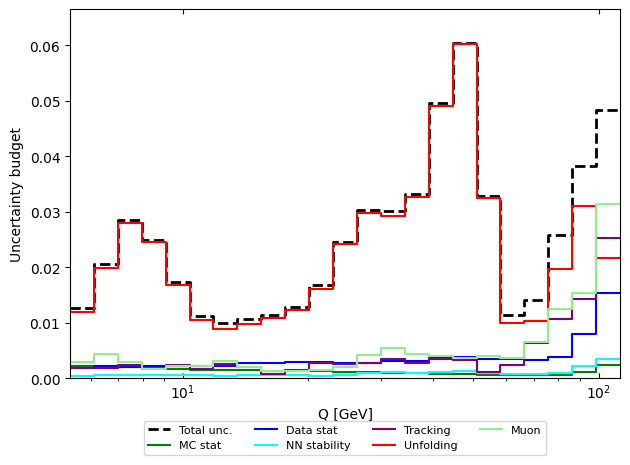

In [15]:
# Plot data measurement and uncertainty budget
import visualize as vis
xsec, budget = vis.plot_measurement_with_uncertainties(
    all_hists,
    measured_label="Data",
    target_key="madgraph",
    target_label="MadGraph",
    target2_key="sherpa",
    target2_label="Sherpa",
    data_measurement_mode=True,
    color="black",
    linear_yscale=True,
)
xsec.show()
budget.show()